# Example solar resource forecast from ECMWF CAMS version of IFS

The ECMWF CAMS global atmospheric composition forecast version of IFS is available via `hefty.solar.get_solar_forecast()`. It requires `cdsapi` to be installed separately (e.g., with `pip install cdsapi`) and the user needs an API key (see https://ads.atmosphere.copernicus.eu/how-to-api).

## Unique features of CAMS
The CAMS version of IFS is different from the open data version of IFS in a few ways:
- hour-intervals (instead of 3-hour)
- different set of parameters, with the addition of clear-sky direct and global irradiance, but the absense of other parameters, particularly 100m wind
- run 2x per day at 00z and 12z (instead of 4x at 00, 06, 12, and 18z)
- goes out 5 days (instead of 10 days, more recently 15 days)
- 0.4°x0.4° resolution (instead of 0.25°x0.25°)

The improved intervals and addition of clear-sky irradiance are the clear benefits over the open data version of IFS.



Import:

In [1]:
from hefty.solar import get_solar_forecast

Read in the users Climate Data Store API key. For this example, the key is saved in a text file named `cams_api_key.txt` and located in the same directory as this notebook. 

See https://ads.atmosphere.copernicus.eu/how-to-api to obtain your own key. 

Your key should then be saved in a text file and look something like this:

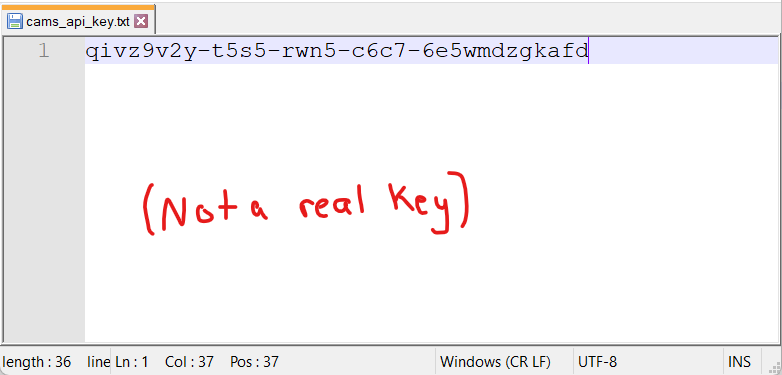

In [2]:
## API key credentials are stored in a separate text file
api_key_file = 'cams_api_key.txt'
with open(api_key_file) as f: # full path and filename of text file with api key on first line
    cams_api_key = f.readline().rstrip()  # rstrip removes trailing line breaks and spaces

CAMS is a global model, but the API allows us to provide latitude/longitude coordinates that define a smaller area reduce the file size of the .grib files that will be returned. For this example, we will use the area bounded by a box  that cover most of the Southeast US, with North-West and South-East corners:
- NW corner: `40, -90` (degrees North, East)
- SE corner: `25, -70` (degrees North, East)

The CAMS API accepts a bounding box in `[North, West, South, East]` format, i.e., `[40, -90, 25, -70]` for the example here. 

Note that this input parameter is optional in hEFTy, and it will default to the full global dataset (`[90, -180, -90, 180]`) if no input is provided.

In [3]:
cams_area = [40, -90, 25, -70]  # [N, W, S, E]

Then we use `get_solar_forecast` just like for other models, but passing the API key string and CAMS area list:

2026-04-24 14:48:44,684 INFO Request ID is f0716d7e-d16f-40e4-bfdd-a79b3f5b2950
2026-04-24 14:48:44,846 INFO status has been updated to accepted
2026-04-24 14:48:59,020 INFO status has been updated to running
2026-04-24 14:59:13,460 INFO status has been updated to successful


50ee1112d4cbd23f94ffbf45224468f1.grib:   0%|          | 0.00/517k [00:00<?, ?B/s]

         Provide tree_name parameter to enable caching.
INFO: 🌱 Growing new BallTree...🌳 Complete in 0.01s


<Axes: xlabel='valid_time'>

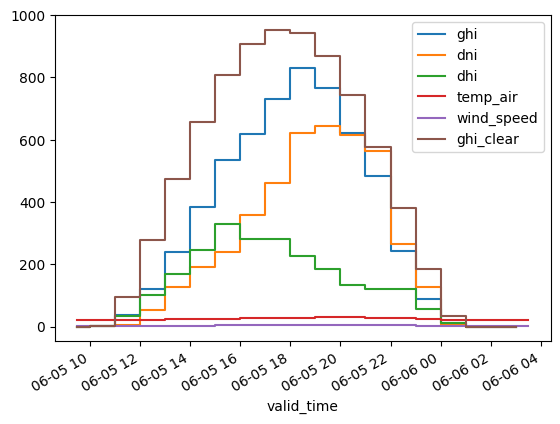

In [4]:
latitude = 33.5
longitude = -86.8
init_date = '2024-06-05 0:00' # datetime the forecast model was initialized
resource_data = get_solar_forecast(
    latitude,
    longitude,
    init_date,
    run_length=18, # 18 hours are included in the forecast
    lead_time_to_start=9, # forecast starts 9 hours out from the init_date
    model='cams', # use ECMWF CAMS version of IFS
    cams_api_key=cams_api_key,
    cams_area=cams_area
)
resource_data[
    ['ghi','dni','dhi','temp_air','wind_speed', 'ghi_clear']
              ].plot(drawstyle='steps-mid')